# Global Population Growth Analysis (1961 - 2024)

### Objectives:
1. **Load and Clean**: Prepare the dataset for analysis by handling missing values and reshaping for time-series work.
2. **Global Trend Analysis**: Identify the overall average global growth pattern.
3. **Regional Insights**: Compare growth rates between major geopolitical regions.
4. **Extremes and Outliers**: Highlight countries with the highest and lowest growth rates in 2024.
5. **Visualizations**: Use high-quality plots to communicate insights effectively.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic parameters for plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
print("All libraries loaded")

All libraries loaded


## 1. Data Loading and Preparation
We start by loading the dataset and performing initial cleaning, such as dropping unnecessary columns and handling null values.

In [41]:
# Load the dataset
file_path = '/kaggle/input/world-population-annual-growth-ratio/popolation_growth.csv'
df = pd.read_csv(file_path)

# Display first few rows and summary information
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (266, 69)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,Population growth (annual %),SP.POP.GROW,NaN,1.187344,1.326227,1.203664,1.076602,0.986114,...,1.023701,0.757968,0.007358,0.158976,0.270505,-0.565684,-0.820211,-0.362774,0.045652,0.590657
1,Africa Eastern and Southern,AFE,Population growth (annual %),SP.POP.GROW,NaN,2.624624,2.687009,2.714042,2.769856,2.809882,...,2.696830,2.640743,2.642067,2.734263,2.721681,2.699516,2.649439,2.592754,2.519167,2.472801
2,Afghanistan,AFG,Population growth (annual %),SP.POP.GROW,NaN,1.962239,2.044523,2.105208,2.161195,2.233709,...,3.119959,2.535720,2.808337,2.910810,2.984389,3.153609,2.356098,1.435704,2.135594,2.836573
3,Africa Western and Central,AFW,Population growth (annual %),SP.POP.GROW,NaN,2.103832,2.131522,2.170015,2.184894,2.216283,...,2.699359,2.672913,2.626296,2.533621,2.440048,2.389176,2.363829,2.332270,2.386204,2.398473
4,Angola,AGO,Population growth (annual %),SP.POP.GROW,NaN,1.327797,0.989639,1.003666,1.027684,1.052133,...,3.605072,3.576441,3.540612,3.453233,3.387884,3.267959,3.181323,3.143026,3.080655,3.044200


### Data Cleaning
The column `1960` appears to be entirely empty in this dataset. We will drop it along with other non-essential indicator columns for a cleaner analysis.

In [42]:
# Drop empty/non-essential columns
cols_to_drop = ['Indicator Name', 'Indicator Code', '1960']
df_clean = df.drop(columns=cols_to_drop)
df_clean.head()

,Country Name,Country Code,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,1.187344,1.326227,1.203664,1.076602,0.986114,0.862399,0.503043,0.133831,...,1.023701,0.757968,0.007358,0.158976,0.270505,-0.565684,-0.820211,-0.362774,0.045652,0.590657
1,Africa Eastern and Southern,AFE,2.624624,2.687009,2.714042,2.769856,2.809882,2.810324,2.844811,2.890531,...,2.696830,2.640743,2.642067,2.734263,2.721681,2.699516,2.649439,2.592754,2.519167,2.472801
2,Afghanistan,AFG,1.962239,2.044523,2.105208,2.161195,2.233709,2.269651,2.306668,2.360683,...,3.119959,2.535720,2.808337,2.910810,2.984389,3.153609,2.356098,1.435704,2.135594,2.836573
3,Africa Western and Central,AFW,2.103832,2.131522,2.170015,2.184894,2.216283,2.249277,2.264622,2.301718,...,2.699359,2.672913,2.626296,2.533621,2.440048,2.389176,2.363829,2.332270,2.386204,2.398473
4,Angola,AGO,1.327797,0.989639,1.003666,1.027684,1.052133,1.070046,1.076727,1.073517,...,3.605072,3.576441,3.540612,3.453233,3.387884,3.267959,3.181323,3.143026,3.080655,3.044200


In [43]:
# Recheck for nulls across years
null_counts = df_clean.isnull().sum().sum()
print(f"Total missing values remaining: {null_counts}")

Total missing values remaining: 96


In [44]:
# Reshape the data for easier plotting (Melting)
df_melted = df_clean.melt(id_vars=['Country Name', 'Country Code'], 
                          var_name='Year', 
                          value_name='Growth Rate')
df_melted.head()

,Country Name,Country Code,Year,Growth Rate
0,Aruba,ABW,1961,1.187344
1,Africa Eastern and Southern,AFE,1961,2.624624
2,Afghanistan,AFG,1961,1.962239
3,Africa Western and Central,AFW,1961,2.103832
4,Angola,AGO,1961,1.327797


In [45]:
# Convert Year to numeric
df_melted['Year'] = pd.to_numeric(df_melted['Year'])
df_melted.head()

,Country Name,Country Code,Year,Growth Rate
0,Aruba,ABW,1961,1.187344
1,Africa Eastern and Southern,AFE,1961,2.624624
2,Afghanistan,AFG,1961,1.962239
3,Africa Western and Central,AFW,1961,2.103832
4,Angola,AGO,1961,1.327797


In [46]:
# Statistical Tests
print(f"Skewness: {df_long['Growth'].skew():.4f}")
print(f"Kurtosis: {df_long['Growth'].kurt():.4f}")


Skewness: 0.6972
Kurtosis: 23.6304


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


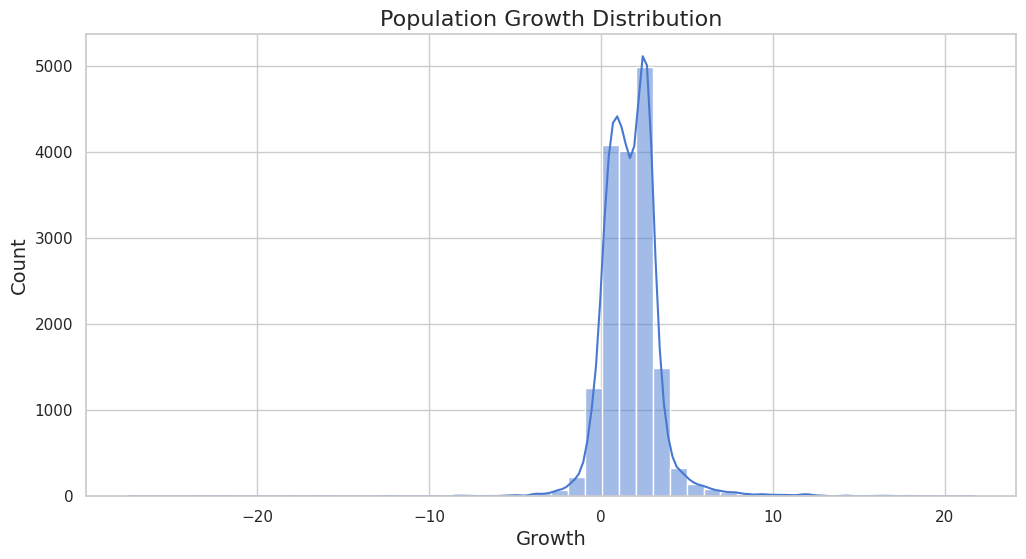

In [47]:
# Visualizing the distribution
sns.histplot(df_long['Growth'], kde=True, bins=50)
plt.title("Population Growth Distribution")
plt.show()

## 2. Average Global Population Growth Trend
How has the global average population growth rate changed over time?

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


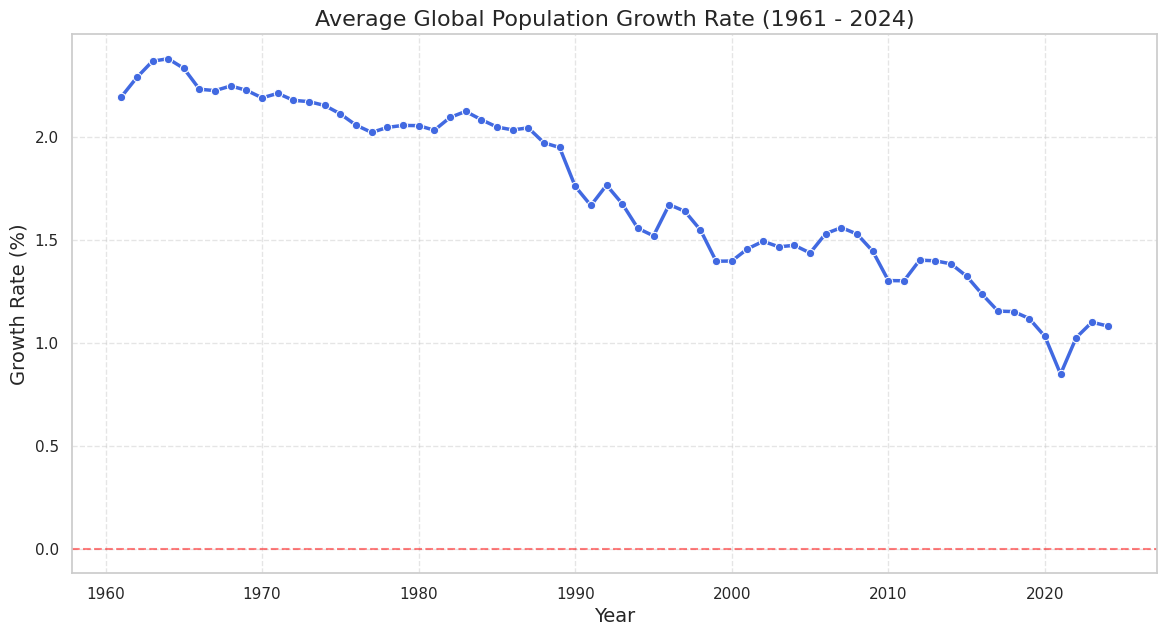

In [48]:
global_trend = df_melted.groupby('Year')['Growth Rate'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=global_trend, x='Year', y='Growth Rate', marker='o', color='royalblue', linewidth=2.5)
plt.title("Average Global Population Growth Rate (1961 - 2024)")
plt.ylabel("Growth Rate (%)")
plt.xlabel("Year")
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

**Insight:** The chart shows a steady decline in the global average population growth rate since the late 1960s, reflecting shifts in demographic transitions across many nations.

## 3. Regional Comparison
Let's compare a few specific regions to see the variance in growth patterns.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

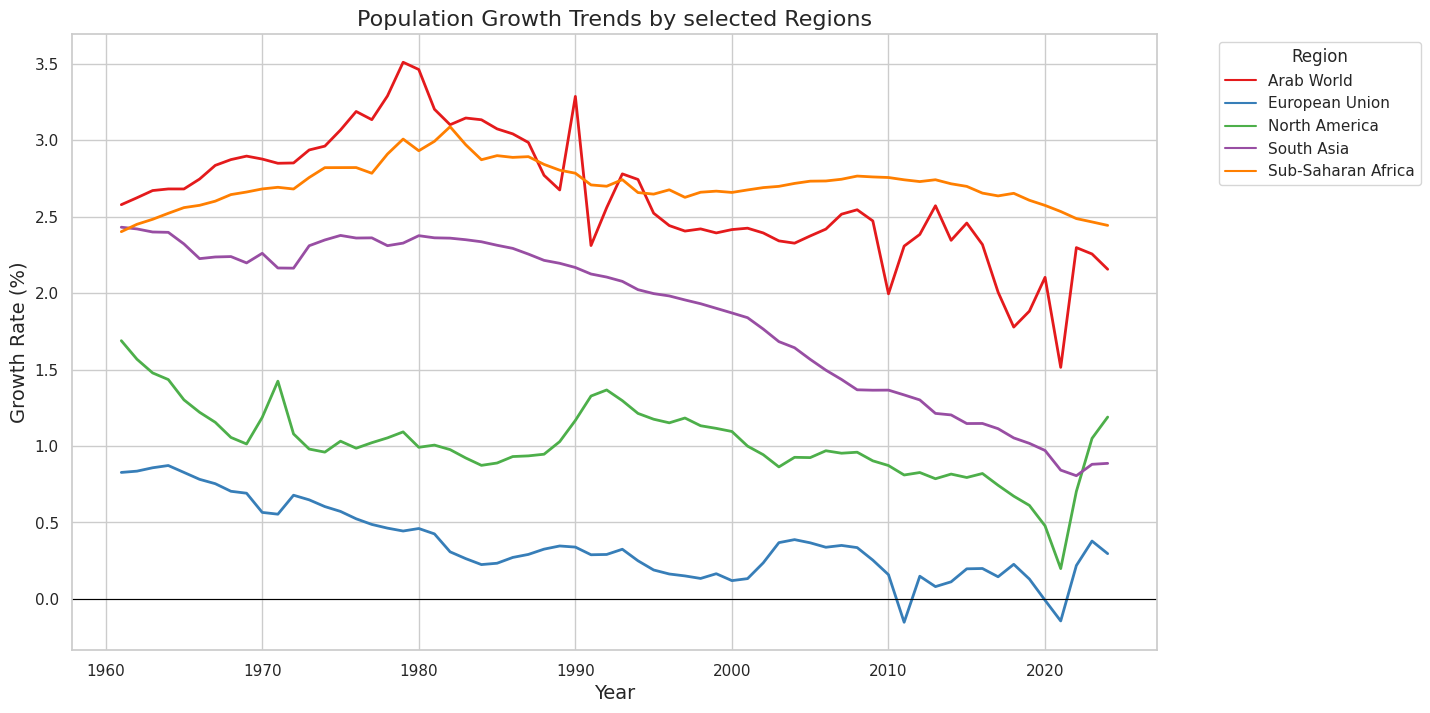

In [49]:
selected_regions = ['Arab World', 'European Union', 'South Asia', 'Sub-Saharan Africa', 'North America']
region_df = df_melted[df_melted['Country Name'].isin(selected_regions)]

plt.figure(figsize=(14, 8))
sns.lineplot(data=region_df, x='Year', y='Growth Rate', hue='Country Name', palette='Set1', linewidth=2)
plt.title("Population Growth Trends by selected Regions")
plt.ylabel("Growth Rate (%)")
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

## 4. Snapshot of 2024: Extremes
Which entities had the highest and lowest growth rates in the most recent year available?

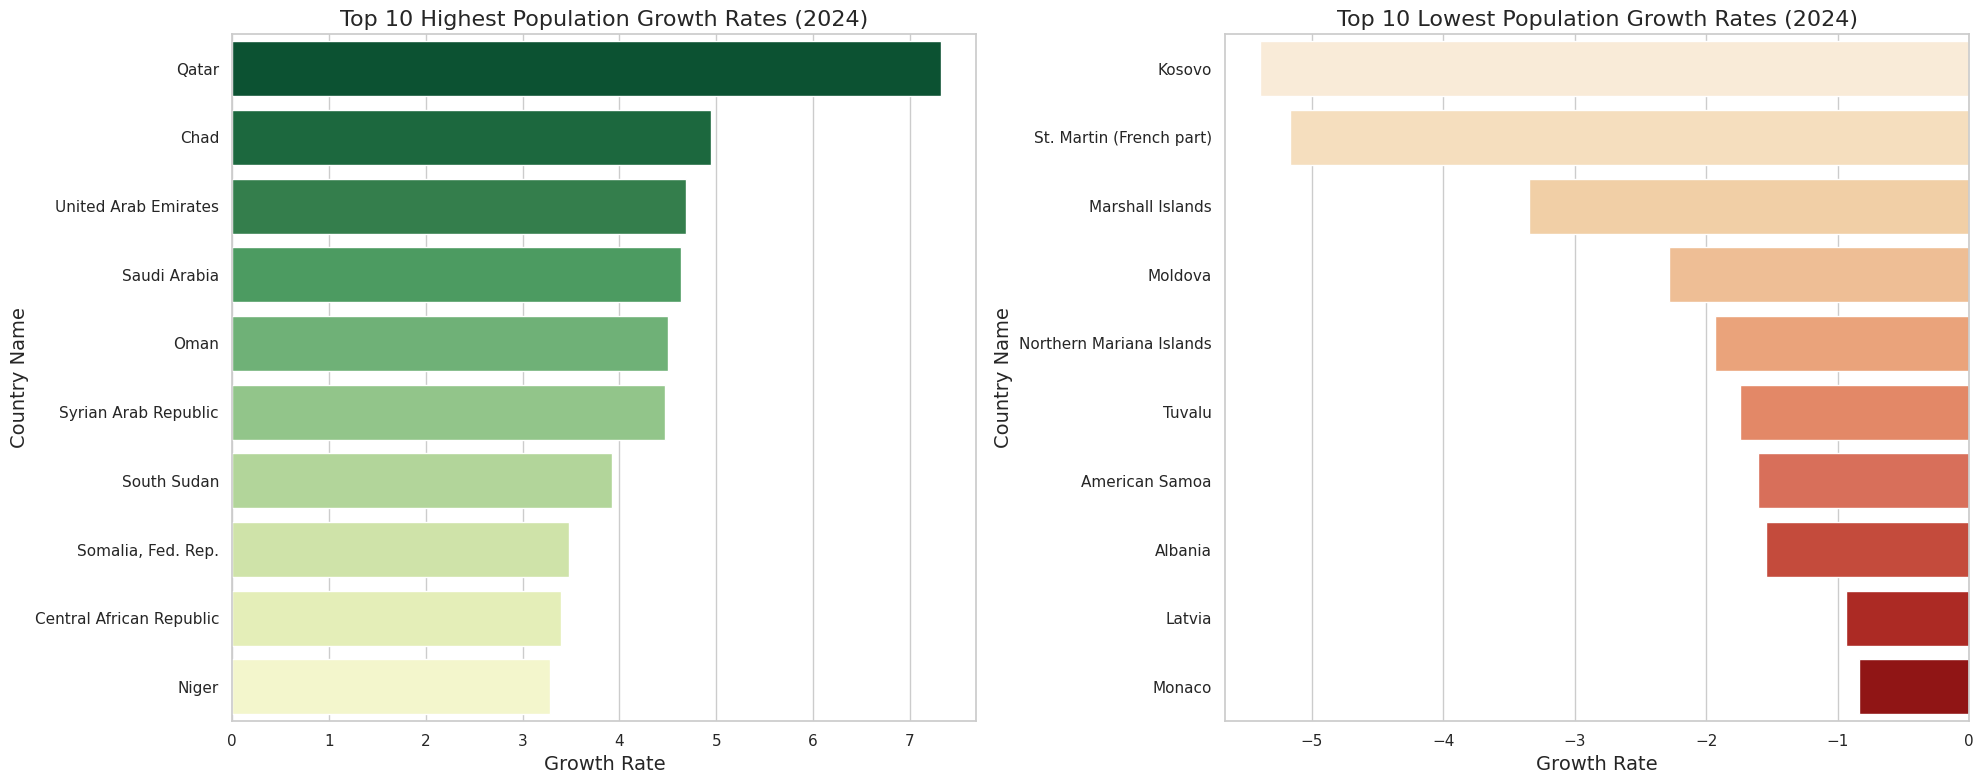

In [50]:
df_2024 = df_melted[df_melted['Year'] == 2024].dropna(subset=['Growth Rate'])

# Get top 10 and bottom 10
top_10 = df_2024.nlargest(10, 'Growth Rate')
bottom_10 = df_2024.nsmallest(10, 'Growth Rate')

fig, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(data=top_10, x='Growth Rate', y='Country Name', ax=ax[0], palette='YlGn_r')
ax[0].set_title("Top 10 Highest Population Growth Rates (2024)")

sns.barplot(data=bottom_10, x='Growth Rate', y='Country Name', ax=ax[1], palette='OrRd')
ax[1].set_title("Top 10 Lowest Population Growth Rates (2024)")

plt.tight_layout()
plt.show()

## 5. Growth Rate Distribution
A boxplot comparison across decades can help us see the spread and concentration of growth rates globally.

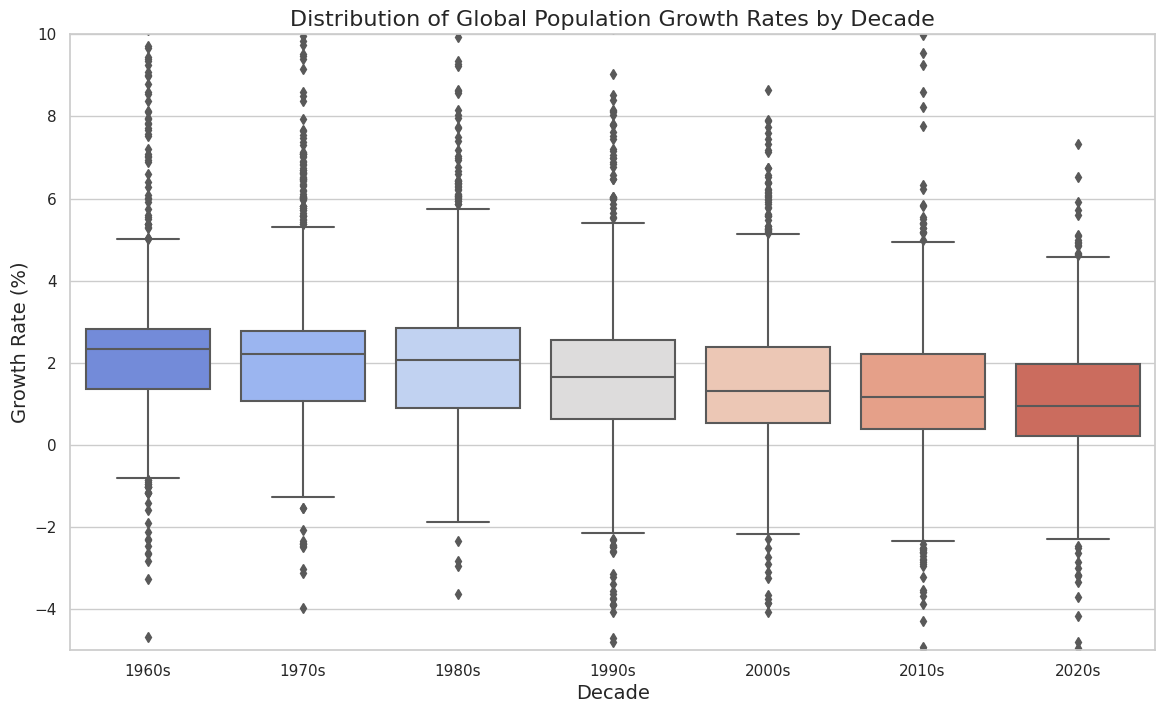

In [51]:
# Create Decade category
df_melted['Decade'] = (df_melted['Year'] // 10) * 10
df_melted['Decade'] = df_melted['Decade'].astype(str) + 's'

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_melted, x='Decade', y='Growth Rate', palette='coolwarm')
plt.title("Distribution of Global Population Growth Rates by Decade")
plt.ylim(-5, 10)  # Limiting for better visibility of bulk data
plt.ylabel("Growth Rate (%)")
plt.show()

In [52]:
from sklearn.preprocessing import LabelEncoder, RobustScaler

df_ml = df_long.copy()

# Create Lags (What was the growth 1 and 2 years ago?)
df_ml['Lag_1'] = df_ml.groupby('Country Code')['Growth'].shift(1)
df_ml['Lag_2'] = df_ml.groupby('Country Code')['Growth'].shift(2)

# Rolling window (Mean of the last 3 years)
df_ml['Rolling_3'] = df_ml.groupby('Country Code')['Growth'].transform(lambda x: x.shift(1).rolling(3).mean())

# Drop the first few years of each country (NaNs from shifting)
df_ml = df_ml.dropna()

# Categorical Encoding
le = LabelEncoder()
df_ml['Country_ID'] = le.fit_transform(df_ml['Country Code'])

In [53]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV

# Split: Use older years for training, recent years (2018+) for testing
train = df_ml[df_ml['Year'] < 2018]
test = df_ml[df_ml['Year'] >= 2018]

X_train, y_train = train[['Year', 'Country_ID', 'Lag_1', 'Lag_2', 'Rolling_3']], train['Growth']
X_test, y_test = test[['Year', 'Country_ID', 'Lag_1', 'Lag_2', 'Rolling_3']], test['Growth']

# Hyperparameter Tuning
gbr = GradientBoostingRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.05]
}
grid = GridSearchCV(gbr, param_grid, cv=3, scoring='neg_mean_absolute_error')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

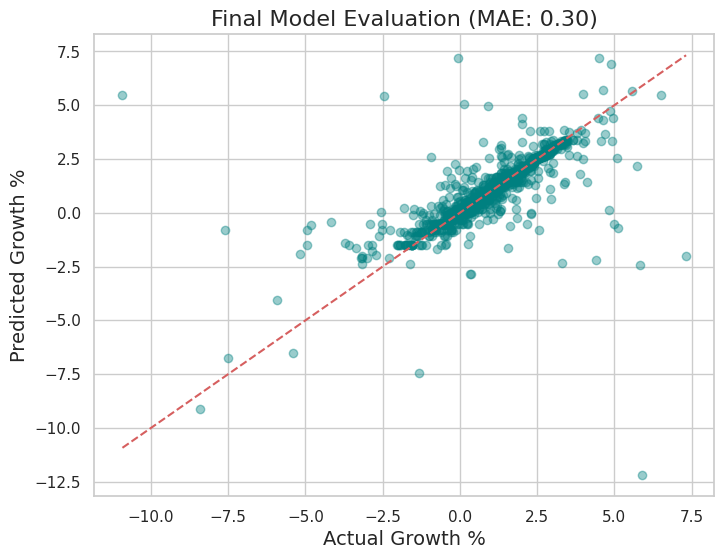

In [54]:
from sklearn.metrics import mean_absolute_error, r2_score

preds = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f"Final Model Evaluation (MAE: {mean_absolute_error(y_test, preds):.2f})")
plt.xlabel("Actual Growth %")
plt.ylabel("Predicted Growth %")
plt.show()

## Conclusion

Through this analysis, we've observed several key trends:
- **Global Deceleration**: There is a clear downward trajectory in the average global population growth rate since the mid-20th century.
- **Regional Disparity**: Some regions continue to see robust growth, while others (like the European Union) are nearing or have reached zero or negative growth.
- **Increased Volatility**: While the mean is dropping, certain countries experience extreme shifts due to migration, economic changes, or conflict.

This notebook serves as a foundation for deeper demographic studies using World Bank data.